In [3]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
from src import config
import numpy as np
from src.utils import visualization as vis
from src.utils import helpers
from src.core.params import BaseParams
from src.models.model import CrowdCounter
from src.data.datamodule import CrowdDataModule

In [4]:
config.DATASET_PATH

'/teamspace/lightning_storage/datasets/ShanghaiTech/part_A'

In [10]:
dataset_path = f'{config.DATA_HOME}/jhu-crowd-pp-v2'

In [12]:
!kaggle datasets download -d swapnilbagde000/jhu-crowdv2-density-maps -p $dataset_path --unzip

Dataset URL: https://www.kaggle.com/datasets/swapnilbagde000/jhu-crowdv2-density-maps
License(s): CC0-1.0

  0%|                                               | 0.00/1.92G [00:00<?, ?B/s]
  1%|▍                                     | 25.0M/1.92G [00:01<01:18, 26.0MB/s]
  3%|█▏                                    | 62.0M/1.92G [00:02<00:59, 33.2MB/s]
  6%|██▎                                    | 118M/1.92G [00:03<00:43, 44.6MB/s]
 10%|███▉                                   | 197M/1.92G [00:04<00:31, 59.4MB/s]
 13%|█████▏                                 | 259M/1.92G [00:05<00:29, 61.4MB/s]
 19%|███████▏                               | 364M/1.92G [00:06<00:21, 77.6MB/s]
 23%|█████████                              | 457M/1.92G [00:07<00:19, 81.0MB/s]
 28%|██████████▊                            | 547M/1.92G [00:08<00:17, 85.0MB/s]
 34%|█████████████▏                         | 661M/1.92G [00:09<00:14, 93.6MB/s]
 39%|███████████████                        | 758M/1.92G [00:10<00:13, 95.9MB/s]
 4

In [9]:
import os

# Define the source path and the target path
old_path = "/teamspace/lightning_storage/datasets/jhu-crowd-pp2/valid"
new_path = "/teamspace/lightning_storage/datasets/jhu-crowd-pp2/val"

# Rename the folder
os.rename(old_path, new_path)

[1.14423707e-01 1.06324345e-01 1.06296465e-01 ... 3.55859821e-11
 3.55859821e-11 3.14941996e-11]


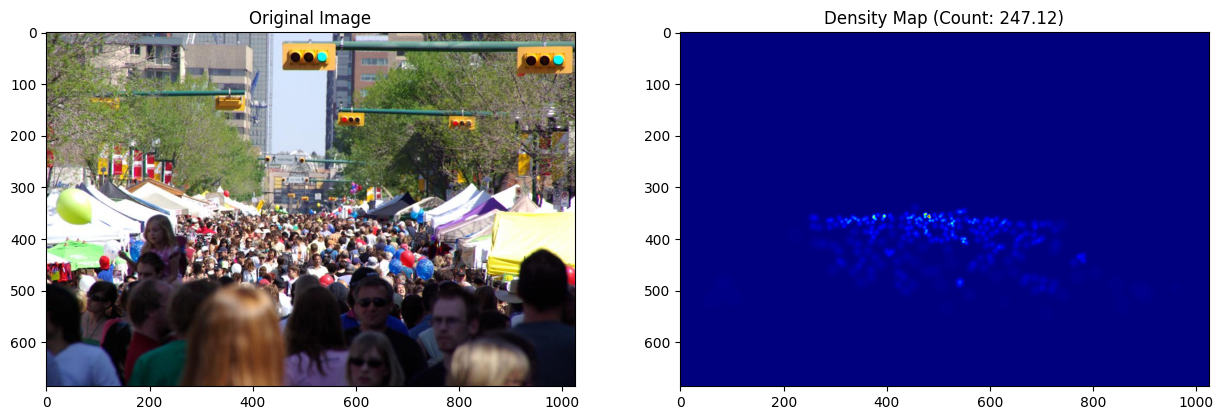

In [ ]:
img, target, count = helpers.get_sample_from_ds(index=12)
print(np.sort(target[target > 0])[::-1])
vis.visualize_sample(img, target, count, cmap='jet')

In [2]:
params = BaseParams(aug_factor=0.12, crop_size=256)
model = CrowdCounter(params)

Unexpected keys (downsamp_modules.0.1.num_batches_tracked, downsamp_modules.1.1.num_batches_tracked, downsamp_modules.2.1.num_batches_tracked, final_layer.1.num_batches_tracked, downsamp_modules.0.0.bias, downsamp_modules.0.0.weight, downsamp_modules.0.1.bias, downsamp_modules.0.1.running_mean, downsamp_modules.0.1.running_var, downsamp_modules.0.1.weight, downsamp_modules.1.0.bias, downsamp_modules.1.0.weight, downsamp_modules.1.1.bias, downsamp_modules.1.1.running_mean, downsamp_modules.1.1.running_var, downsamp_modules.1.1.weight, downsamp_modules.2.0.bias, downsamp_modules.2.0.weight, downsamp_modules.2.1.bias, downsamp_modules.2.1.running_mean, downsamp_modules.2.1.running_var, downsamp_modules.2.1.weight, final_layer.0.bias, final_layer.0.weight, final_layer.1.bias, final_layer.1.running_mean, final_layer.1.running_var, final_layer.1.weight, classifier.bias, classifier.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup()

In [4]:
sample = helpers.get_sample_from_dm(datamodule)
sample.shape

torch.Size([1, 3, 672, 992])

In [ ]:
vis.visualize_model_graph(model, sample=sample)

In [5]:
from torchview import draw_graph
model_graph = draw_graph(model, input_size=sample.shape, expand_nested=True, depth=100)
model_graph.visual_graph